## Práctica 2: Regresión lineal con BGD
Programa 1

#### Escuela Superior de Cómputo
Ingeniería en IA
<br>
Aprendizaje Automático<br>
**Robles Guzmán Naomi Isabel** <br><br>

<p>Consuelo Varinia García Mendoza</p>
<br>

---

## Especificaciones

### I. Elabora un programa en python que implemente BGD monovariable sin sesgo
* Entrada: archivo *casas.csv* número de interaciones, peso inicial y $\alpha$


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split


In [2]:

# Leer datos
df = pd.read_csv('casas.csv')

# Parámetros de entrada
num_iteraciones = 5
peso_inicial = 0
alpha =  7e-8

X = df['Terreno (m2)']
y = df['Precio (MDP)']


### II. Divide *casa.csv* en 70% para entrenamiento y 30% para pruebas. 
con los parámetros shuffle=True  y random_state = 0

Usando la función **sklearn.model_selection.train_test_split(*arrays, test_size=None, train_size=None, random_state=None, shuffle=True, stratify=None)**


In [3]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state = 0, shuffle=True)

---
### a) Definir función para implementar el algoritmo BGD
$$
w_i = w_i - 2\alpha \sum_{j=0}^{m-1}(w_i \cdot X_{i,j} - y_j) \cdot X_{j,i}
$$

In [4]:
# Inicializar peso
w = peso_inicial


# Listas para almacenar resultados
pesos_historia = []
y_pred_historia = []
errores = []

# algoritmo BGD sin sesgo
for iteracion in range(num_iteraciones):
    # Guardar peso actual
    pesos_historia.append(w)
    
    # Actualizar peso usando la fórmula BGD sin sesgo
    incremento_peso = np.dot((w * X_train - y_train), X_train)
    
    w = w - 2 * alpha * incremento_peso

    # Predicciones en conjunto de prueba
    y_pred_test = w * X_test
    y_pred_historia.append(y_pred_test.copy())
    
    # Calcular error de estimación (suma de diferencias absolutas)
    error = np.sum(np.abs(y_pred_test - y_test))
    errores.append(error)


### III. Salida:
* peso en cada iteración
* y_test
* y_pred en cada iteración

b) Establecemos los parámetros y aplicamos la función


-----------[ w ]-------------------

Iteración 0 : [0]
Iteración 1 : [0.0008143828000000002]
Iteración 2 : [0.0013405466503074801]
Iteración 3 : [0.0016804953788051747]
Iteración 4 : [0.0019001325468463945]

----------[ y_test ]---------------

[0.88 1.63 0.99]

----------[ y_pred ]---------------

Iteración 0 : [0.31027985 0.57658302 0.35099899]
Iteración 1 : [0.51074827 0.94910703 0.57777561]
Iteración 2 : [0.64026874 1.1897907 0.72429351]
Iteración 3 : [0.7239505 1.3452938 0.81895713]
Iteración 4 : [0.77801637 1.4457627 0.88011826]

---------[ Error de estimación ] ---

Iteración 0 : 2.262138144
Iteración 1 : 1.46236909153263
Iteración 2 : 0.9456470242161344
Iteración 3 : 0.6117985287934804
Iteración 4 : 0.396102654849504


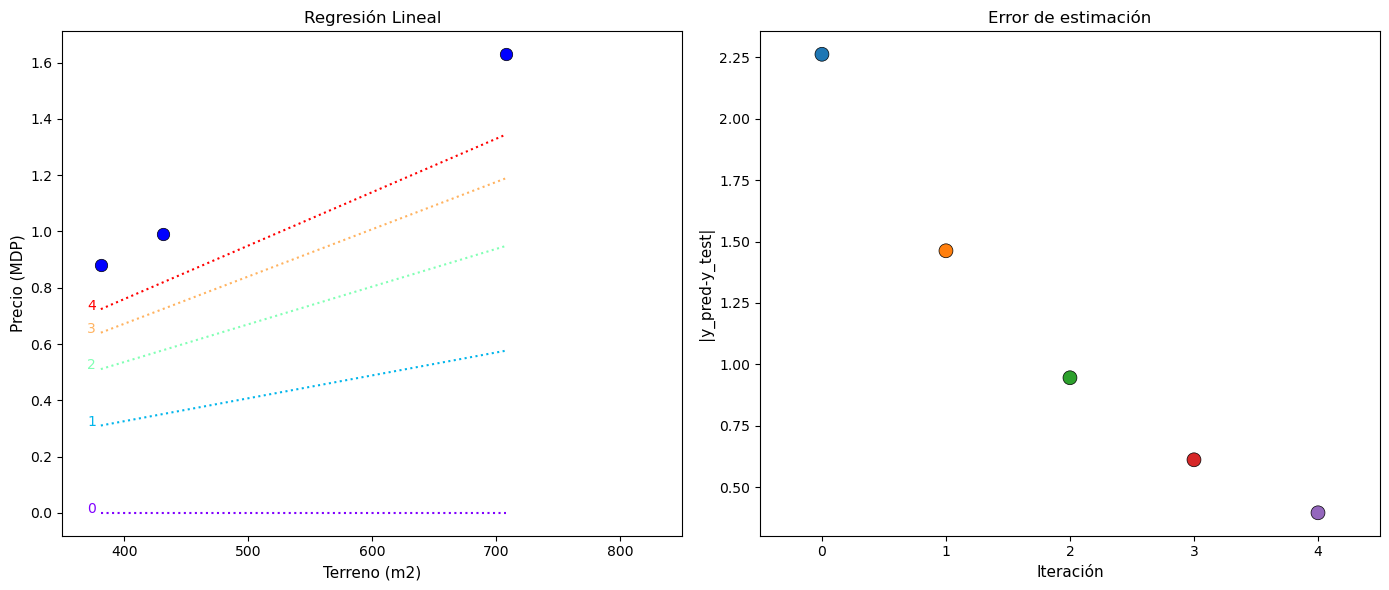

In [5]:

# Imprimir resultados
print("\n-----------[ w ]-------------------\n")
for i in range(num_iteraciones):
    print(f"Iteración {i} : [{pesos_historia[i]}]")

print("\n----------[ y_test ]---------------\n")
print(f"[{' '.join([f'{val:.2f}' for val in y_test])}]")

print("\n----------[ y_pred ]---------------\n")
for i in range(num_iteraciones):
    pred_str = ' '.join([f'{val:.8g}' for val in y_pred_historia[i]])
    print(f"Iteración {i} : [{pred_str}]")

print("\n---------[ Error de estimación ] ---\n")
for i in range(num_iteraciones):
    print(f"Iteración {i} : {errores[i]:.16g}")
    

# Crear las gráficas
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Gráfica 1: Regresión Lineal con múltiples iteraciones
colores = plt.cm.rainbow(np.linspace(0, 1, num_iteraciones))
X_sorted = np.sort(X_test)

for i in range(num_iteraciones):
    y_line = pesos_historia[i] * X_sorted
    estilo = ':'
    ax1.plot(X_sorted, y_line, color=colores[i], linestyle=estilo, linewidth=1.5, label=f'{i}')

ax1.scatter(X_test, y_test, color='blue', s=80, zorder=5, edgecolors='black', linewidth=0.5)

# Agregar etiquetas de iteración cerca de las líneas
for i in range(num_iteraciones):
    y_pos = pesos_historia[i] * 380
    ax1.text(370, y_pos, str(i), fontsize=10, color=colores[i])

ax1.set_xlabel('Terreno (m2)', fontsize=11)
ax1.set_ylabel('Precio (MDP)', fontsize=11)
ax1.set_title('Regresión Lineal', fontsize=12)
ax1.grid(False)
ax1.set_xlim(350, 850)

# Gráfica 2: Error de estimación
colores_error = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
ax2.scatter(range(num_iteraciones), errores, 
           s=100, c=colores_error[:num_iteraciones], zorder=5, edgecolors='black', linewidth=0.5)

ax2.set_xlabel('Iteración', fontsize=11)
ax2.set_ylabel('|y_pred-y_test|', fontsize=11)
ax2.set_title('Error de estimación', fontsize=12)
ax2.grid(False)
ax2.set_xlim(-0.5, num_iteraciones - 0.5)

plt.tight_layout()
plt.show()

* Error de estimación
* Gráfica 1: distribución de los datos de prueba y_pred en cada iteración
* Gráfica 2: error de estimación en cada iteración